In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [40]:
diabetes_dataset = pd.read_csv('diabetes.csv')

In [41]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [42]:
diabetes_dataset.shape

(768, 9)

In [43]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [44]:
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [45]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [46]:
diabetes_dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [47]:
diabetes_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [48]:
(diabetes_dataset == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [49]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((diabetes_dataset[columns] == 0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [50]:
X = diabetes_dataset.drop(columns='Outcome', axis=1)
y = diabetes_dataset['Outcome']

In [51]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [52]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


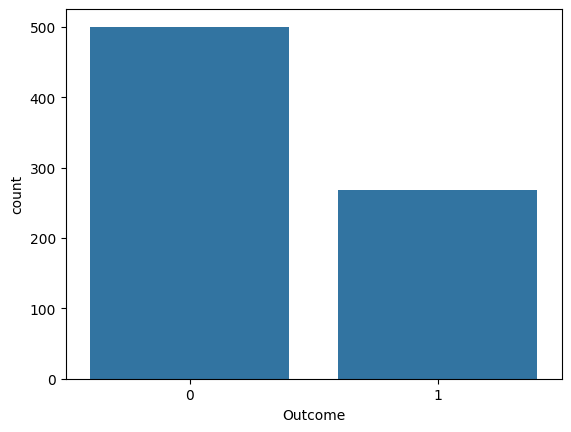

In [53]:
sns.countplot(x='Outcome', data=diabetes_dataset)
plt.show()

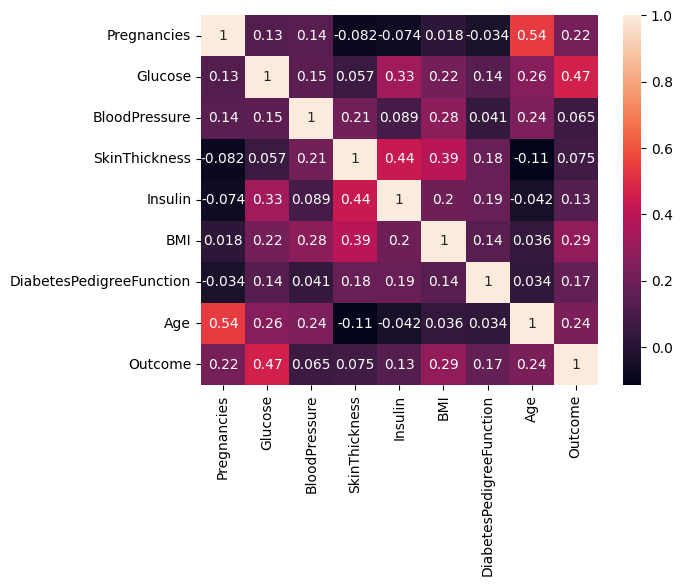

In [54]:
sns.heatmap(diabetes_dataset.corr(), annot=True)
plt.show()

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [56]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


In [57]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90,62,12,43,27.2,0.580,24
711,5,126,78,27,22,29.6,0.439,40
373,2,105,58,40,94,34.9,0.225,25
46,1,146,56,0,0,29.7,0.564,29
682,0,95,64,39,105,44.6,0.366,22
...,...,...,...,...,...,...,...,...
451,2,134,70,0,0,28.9,0.542,23
113,4,76,62,0,0,34.0,0.391,25
556,1,97,70,40,0,38.1,0.218,30
667,10,111,70,27,0,27.5,0.141,40


In [58]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159,64,0,0,27.4,0.294,40
672,10,68,106,23,49,35.5,0.285,47
700,2,122,76,27,200,35.9,0.483,26
630,7,114,64,0,0,27.4,0.732,34
81,2,74,0,0,0,0.0,0.102,22
...,...,...,...,...,...,...,...,...
32,3,88,58,11,54,24.8,0.267,22
637,2,94,76,18,66,31.6,0.649,23
593,2,82,52,22,115,28.5,1.699,25
425,4,184,78,39,277,37.0,0.264,31


In [59]:
y_train

,Outcome
353,0
711,0
373,0
46,0
682,0
...,...
451,1
113,0
556,0
667,1


In [60]:
y_test

,Outcome
44,0
672,0
700,0
630,1
81,0
...,...
32,0
637,0
593,0
425,1


In [61]:
scaler = StandardScaler()

In [62]:
scaler.fit(X_train)

StandardScaler()

In [63]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
print(X_train)

[[-0.85135507 -0.98013068 -0.40478372 ... -0.60767846  0.31079384
  -0.79216928]
 [ 0.35657564  0.16144422  0.46536842 ... -0.30213902 -0.11643851
   0.56103382]
 [-0.5493724  -0.50447447 -0.62232176 ...  0.3725939  -0.76486207
  -0.70759409]
 ...
 [-0.85135507 -0.75815778  0.03029235 ...  0.77997981 -0.78607218
  -0.28471812]
 [ 1.86648903 -0.31421198  0.03029235 ... -0.56948603 -1.01938346
   0.56103382]
 [ 0.05459296  0.73223168 -0.62232176 ... -0.31486983 -0.57700104
   0.30730824]]


In [65]:
print(X_test)

[[ 0.96054099  1.20788789 -0.29601471 ... -0.58221684 -0.55579092
   0.56103382]
 [ 1.86648903 -1.67775979  1.98813468 ...  0.44897876 -0.58306107
   1.15306018]
 [-0.5493724   0.03460257  0.3565994  ...  0.499902    0.01688223
  -0.6230189 ]
 ...
 [-0.5493724  -1.23381399 -0.94862882 ... -0.44217793  3.70138246
  -0.70759409]
 [ 0.05459296  2.00064824  0.46536842 ...  0.6399409  -0.64669142
  -0.20014293]
 [-0.85135507 -1.58262854  0.46536842 ...  0.15617013 -0.16794879
  -1.04589487]]


In [66]:
model = svm.SVC(kernel='linear')

In [67]:
model.fit(X_train, y_train)

SVC(kernel='linear')

In [68]:
training_data_prediction = model.predict(X_train)

In [69]:
training_data_accuracy = accuracy_score(training_data_prediction, y_train)

In [70]:
print('Accuracy on training data : ', training_data_accuracy)

Accuracy on training data :  0.7915309446254072


In [71]:
testing_data_prediction = model.predict(X_test)

In [72]:
testing_data_accuracy = accuracy_score(testing_data_prediction, y_test)

In [73]:
print('Accuracy on testing data : ', testing_data_accuracy)

Accuracy on testing data :  0.7207792207792207


In [74]:
input_data = (1,85,66,29,0,26.6,0.351,31)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshape = input_data_as_numpy_array.reshape(1, -1)

std_data = scaler.transform(input_data_reshape)

prediction = model.predict(std_data)

print(prediction)

if prediction[0] == 0:
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[0]
The person is not diabetic
